In [2]:
#импорт библиотек
import pandas as pd 
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
from comet_ml import Experiment

In [4]:
# Создайте эксперимент с помощью вашего API ключа
experiment = Experiment(
    api_key="HfRy2c5MeV330RQh6uFcMU4QC",
    project_name="medical-appointment",
    workspace="natalia-kuvshinnikova",
)

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/natalia-kuvshinnikova/medical-appointment/325bc83eb66d426ca013cee1e0e39afb



In [5]:
df = pd.read_csv('data/KaggleV2-May-2016.csv')

In [6]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [7]:
# Удалим аномальные значения возраста пациентов
df = df[(df.Age >= 0) & (df.Age <= 110)]
df.Age.value_counts()

Age
0      3539
1      2273
52     1746
49     1652
53     1651
       ... 
97       11
98        6
100       4
102       2
99        1
Name: count, Length: 102, dtype: int64

## Числовые признаки

In [8]:
numeric_data=df.drop(['AppointmentID', 'PatientId','Gender' ,'ScheduledDay', 'AppointmentDay', 'Neighbourhood', 'No-show'], axis=1, inplace = False)

In [9]:

numeric_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110521 entries, 0 to 110526
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   Age           110521 non-null  int64
 1   Scholarship   110521 non-null  int64
 2   Hipertension  110521 non-null  int64
 3   Diabetes      110521 non-null  int64
 4   Alcoholism    110521 non-null  int64
 5   Handcap       110521 non-null  int64
 6   SMS_received  110521 non-null  int64
dtypes: int64(7)
memory usage: 6.7 MB


{'web': 'https://www.comet.com/api/image/download?imageId=12e50f1454b54261a5fd27c656bed58d&experimentKey=325bc83eb66d426ca013cee1e0e39afb',
 'api': 'https://www.comet.com/api/rest/v1/image/get-image?imageId=12e50f1454b54261a5fd27c656bed58d&experimentKey=325bc83eb66d426ca013cee1e0e39afb',
 'imageId': '12e50f1454b54261a5fd27c656bed58d'}

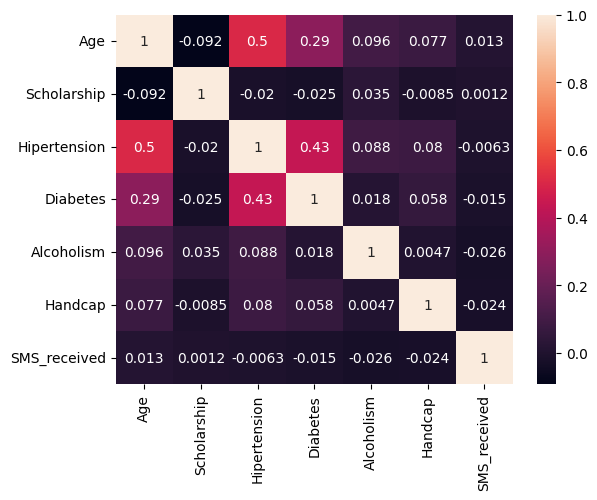

In [10]:
sns.heatmap(numeric_data.corr(), annot = True)
#логируем тепловую карту
experiment.log_figure(figure=plt)

Мультиколлинеарные признаки отсутствуют. Наибольшая корреляция наблюдается между признаками возраста и повышенного давления, а также высока корреляция между признаками возраста и наличия диабета, наличия диабета и повышенного давления.